In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords


In [ ]:
df=pd.read_csv("/content/train.csv")
df

,Unnamed: 0,id,excerpt,target,standard_error,fr,th,tr,ur,ru,bg,de,ar
0,0,c12129c31,When the young people returned to the ballroom...,-0.340259,0.464009,"When young people returned to the ballroom, he...",When young people return to the ballroom It sh...,"When the teenagers return to the ballroom, it ...","When the youth returned to the ballroom, it pr...","When young people returned to the ballroom, he...","When young people returned to the ballroom, he...",When the young people returned to the ballroom...,"When young people returned to the dance hall, ..."
1,1,85aa80a4c,"All through dinner time, Mrs. Fayre was somewh...",-0.315372,0.480805,"Throughout the dinner, Ms. Fayre was a little ...","Throughout the dinner, Mrs. Filera was quiet. ...","At the time of all dinner, Ms. Fayre was a bit...","At the time of dinner, Mrs. Ferry was silent, ...",The time of all dent Mrs. Fair was somewhat si...,"All the time of dinner, Mr. Fory was a little ...","During the entire dinner, Mrs. Fayre was silen...","All through dinner time, Ms. Fire was fairly s..."
2,2,b69ac6792,"As Roger had predicted, the snow departed as q...",-0.580118,0.476676,"While Roger had predicted, the snow left the f...",When Rogers predicts that the snow will leave ...,"As the Roger is foreseen, the profit was separ...","As the Roger predicted, as soon as Issued, and...","As Roger predicted, the snow left so quickly, ...","As Roger predicts, the snow left as fast as he...","As Roger had predicted, the snow drove as fast...","As Roger predicted, snow left as fast as he ca..."
3,3,dd1000b26,And outside before the palace a great garden w...,-1.054013,0.450007,"And outdoors before the palace, a large garden...",And the outside before the palace has a garden...,"Prior to palace, a large garden, round-walled,...",And before the palace was a great garden gold ...,"And outside the palace, the Great Garden was s...",And out in front of the palace a large garden ...,"And outside, before the palace walls a great g...",Outdoor before the palace was a wonderful gard...
4,4,37c1b32fb,Once upon a time there were Three Bears who li...,0.247197,0.510845,Once upon a time there were three bears who li...,"Once upon a time, there were three bears who l...","Once upon a time, there was three months livin...",Once there were three bears that lived togethe...,Once there were three bear who lived together ...,Once there were three bears that lived togethe...,There was once three bears living in a private...,Once there were three pills who lived together...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2829,2829,25ca8f498,When you think of dinosaurs and where they liv...,1.711390,0.646900,When you think of the dinosaurs and where they...,When you think of the dinosaurs and where they...,When you think of dinosaurs and where they liv...,When you think about dinosaurs and where did y...,When do you think about dinosales and where di...,When you think about dinosaurs and where they ...,If you think of dinosaurs and where they lived...,When you think about the dinosaurs and where t...
2830,2830,2c26db523,So what is a solid? Solids are usually hard be...,0.189476,0.535648,So what is a solid? The solids are usually dif...,So what is solid? Solid is often difficult bec...,"Well, what is the robust? Solids are usually d...",So what is solid? Solid is usually difficult b...,So what is the most solid? The solids are usua...,So what is solid? Solid substances are usually...,So what is a solids? Solids are usually diffic...,So is solid? Solid material is usually difficu...
2831,2831,cd19e2350,The second state of matter we will discuss is ...,0.255209,0.483866,The second state of the material we are going ...,"The second state of the matter, we will discus...",The second situation of the second situation w...,The other condition of the matter will communi...,The second state of matter we will discuss is ...,The second state we will discuss is a liquid. ...,The second state of matter we discuss

In [ ]:
df['excerpt_lower']=df['excerpt'].str.lower()
df[['excerpt','excerpt_lower']].head()

,excerpt,excerpt_lower
0,When the young people returned to the ballroom...,when the young people returned to the ballroom...
1,"All through dinner time, Mrs. Fayre was somewh...","all through dinner time, mrs. fayre was somewh..."
2,"As Roger had predicted, the snow departed as q...","as roger had predicted, the snow departed as q..."
3,And outside before the palace a great garden w...,and outside before the palace a great garden w...
4,Once upon a time there were Three Bears who li...,once upon a time there were three bears who li...


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()

{'such', "we'd", "you've", 'aren', "they've", 'haven', 'who', 'down', "i'll", 'own', 'just', 'ours', 'too', 'up', 'my', 'only', "he'll", 'but', "didn't", "haven't", 'this', "shouldn't", "that'll", "he'd", 'them', "aren't", 'a', "it's", 'shan', 'am', 'wasn', 'is', 'hadn', 'i', 'weren', "we've", 'with', 'o', 'which', "they'd", 'we', 'each', 'from', 'myself', 'had', 'him', 'under', 'hasn', 'been', 'do', 'will', "wouldn't", 'y', "i'm", 'himself', 'out', 'doesn', 'ourselves', "we'll", 'at', "she'll", "couldn't", 're', 'has', 'than', 'or', 'in', 'some', 'her', 'through', 'why', 've', 'nor', "we're", 'very', 'when', 'be', 'all', 'that', 'few', 'ma', 'below', 'on', 'there', 'does', 'same', 'during', "isn't", 'how', 'what', 'he', 'of', 'more', 'itself', 'most', "hasn't", "needn't", 'm', 'didn', 'doing', "wasn't", "shan't", 'whom', "you're", 'having', 'into', 'themselves', 'your', 'both', 'mustn', 'its', 'should', "mustn't", 'his', "they're", 'yourself', 'over', 'have', 'until', 'hers', 'being',

In [ ]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filtered_tokens=[word for word in word_tokens if word.lower() not in stop_words ]
  lemmatized_tokens=[lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]
  return{
      'original_text':text,
      'word_tokens':word_tokens,
      'filtered_tokens':filtered_tokens
  }

  results=df['excerpt'].apply(process_text)
  processed_df=pd.DataFrame(results.tolist()) #convert results to a dataframe
  print(processed_df.head())  #display processed dataframe

  processed_file_path="processed_nlp_dataset.csv"  #save processed results to a new csv file
  processed_df.to_csv(processed_file_path,index=False)
  print(f"Processed dataset saved to {processed_file_path}")


In [ ]:
from nltk.stem import PorterStemmer,WordNetLemmatizer
stemmer=PorterStemmer()
def stem_text(Text):
  tokens=word_tokenize(str(Text))
  stemmed_tokens=[stemmer.stem(word) for word in tokens]
  return stemmed_tokens
df['stemmed']=df['excerpt'].apply(stem_text)

In [ ]:
df[['excerpt','stemmed']].head(10)

,excerpt,stemmed
0,When the young people returned to the ballroom...,"[when, the, young, peopl, return, to, the, bal..."
1,"All through dinner time, Mrs. Fayre was somewh...","[all, through, dinner, time, ,, mrs., fayr, wa..."
2,"As Roger had predicted, the snow departed as q...","[as, roger, had, predict, ,, the, snow, depart..."
3,And outside before the palace a great garden w...,"[and, outsid, befor, the, palac, a, great, gar..."
4,Once upon a time there were Three Bears who li...,"[onc, upon, a, time, there, were, three, bear,..."
5,Hal and Chester found ample time to take an in...,"[hal, and, chester, found, ampl, time, to, tak..."
6,Hal Paine and Chester Crawford were typical Am...,"[hal, pain, and, chester, crawford, were, typi..."
7,"On the twenty-second of February, 1916, an aut...","[on, the, twenty-second, of, februari, ,, 1916..."
8,The boys left the capitol and made their way d...,"[the, boy, left, the, capitol, and, made, thei..."
9,One day he had gone beyond any point which he ...,"[one, day, he, had, gone, beyond, ani, point, ..."


In [ ]:
def lemmatize_text(Text):
  tokens=word_tokenize(str(Text))
  lemmatized_tokens=[lemmatizer.lemmatize(word) for word in tokens]
  return lemmatized_tokens

df['lemmatized']=df['excerpt'].apply(lemmatize_text)
df[['excerpt','lemmatized']].head(10)

,excerpt,lemmatized
0,When the young people returned to the ballroom...,"[When, the, young, people, returned, to, the, ..."
1,"All through dinner time, Mrs. Fayre was somewh...","[All, through, dinner, time, ,, Mrs., Fayre, w..."
2,"As Roger had predicted, the snow departed as q...","[As, Roger, had, predicted, ,, the, snow, depa..."
3,And outside before the palace a great garden w...,"[And, outside, before, the, palace, a, great, ..."
4,Once upon a time there were Three Bears who li...,"[Once, upon, a, time, there, were, Three, Bear..."
5,Hal and Chester found ample time to take an in...,"[Hal, and, Chester, found, ample, time, to, ta..."
6,Hal Paine and Chester Crawford were typical Am...,"[Hal, Paine, and, Chester, Crawford, were, typ..."
7,"On the twenty-second of February, 1916, an aut...","[On, the, twenty-second, of, February, ,, 1916..."
8,The boys left the capitol and made their way d...,"[The, boy, left, the, capitol, and, made, thei..."
9,One day he had gone beyond any point which he ...,"[One, day, he, had, gone, beyond, any, point, ..."


In [ ]:

from sklearn.feature_extraction.text import CountVectorizer



In [ ]:
text_data=df['excerpt'].astype(str)
vectorizer=CountVectorizer()
bow_matrix=vectorizer.fit_transform(text_data)
bow_df=pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("Vocabulary: ")
print(vectorizer.vocabulary_)
print(vectorizer.get_feature_names_out)
print(bow_df.head())
print("\nShape")
print(bow_matrix.shape)
bow_df.to_csv("bag_of_words.csv",index=False)
print("\nBag of words saved as 'bag_of_words.csv'")

Vocabulary: 
{'when': 26221, 'the': 24026, 'young': 26745, 'people': 17616, 'returned': 20201, 'to': 24327, 'ballroom': 2366, 'it': 13083, 'presented': 18634, 'decidedly': 6527, 'changed': 4358, 'appearance': 1646, 'instead': 12719, 'of': 16655, 'an': 1402, 'interior': 12828, 'scene': 20985, 'was': 26019, 'winter': 26415, 'landscape': 13756, 'floor': 9605, 'covered': 5906, 'with': 26448, 'snow': 22171, 'white': 26277, 'canvas': 3956, 'not': 16406, 'laid': 13708, 'on': 16733, 'smoothly': 22127, 'but': 3736, 'rumpled': 20665, 'over': 17005, 'bumps': 3652, 'and': 1438, 'hillocks': 11622, 'like': 14125, 'real': 19540, 'field': 9345, 'numerous': 16486, 'palms': 17210, 'evergreens': 8686, 'that': 24022, 'had': 11090, 'decorated': 6558, 'room': 20520, 'were': 26181, 'powdered': 18493, 'flour': 9627, 'strewn': 23058, 'tufts': 24850, 'cotton': 5830, 'also': 1287, 'diamond': 6994, 'dust': 7816, 'been': 2629, 'lightly': 14117, 'sprinkled': 22626, 'them': 24038, 'glittering': 10545, 'crystal': 616

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

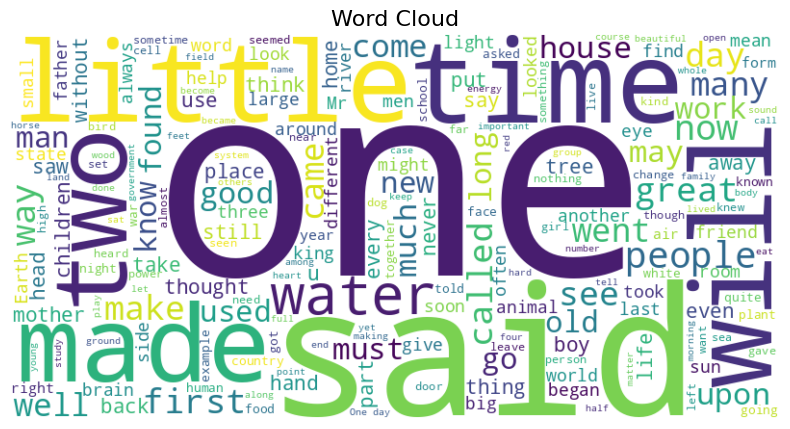

In [ ]:
text_data=" ".join(df['excerpt'].astype(str).dropna())
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud",fontsize=16)
plt.show()